<a href="https://colab.research.google.com/github/Prakriti1103/Car-Purchase-Amount-Prediction/blob/main/car_sales_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🚗 Car Purchase Amount Prediction using ANN

## 📌 Problem Statement
The objective of this project is to build a machine learning model that predicts the **car purchase amount** based on customer demographic and financial attributes.

## 🎯 Goal
To understand customer purchasing power and estimate how much a customer is likely to spend on a car.

## 📊 Features Used
- Gender
- Age
- Annual Salary
- Credit Card Debt
- Net Worth

## 🎯 Target Variable
- Car Purchase Amount


In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

from keras.models import Sequential
from keras.layers import Dense

In [3]:
#import dataset
car_df = pd.read_csv('/content/car_sales_synthetic_dataset.csv', encoding = 'ISO-8859-1')
car_df



,ï»¿Customer Name,Customer Email,Country,Gender,Age,Annual Salary,Credit Card Debt,Net Worth,Car Purchase Amount
0,Priya Nair,priya.nair@outlook.com,France,0,58,45795,1860,415838,96167
1,Rohit Gupta,rohit.gupta@outlook.com,Germany,1,40,84886,7265,571430,135545
2,Sneha Singh,sneha.singh@hotmail.com,Brazil,1,30,142727,12363,241335,88225
3,Ankit Singh,ankit.singh@gmail.com,Canada,1,41,94820,1769,371879,103886
4,Amit Verma,amit.verma@yahoo.com,Australia,0,21,35311,6051,285796,60911
...,...,...,...,...,...,...,...,...,...
195,Pooja Singh,pooja.singh@hotmail.com,Singapore,0,25,101158,7767,208211,70092
196,Pooja Malhotra,pooja.malhotra@yahoo.com,Canada,0,49,43918,14046,573138,124214
197,Rohit Nair,rohit.nair@gmail.com,Australia,0,50,145751,5324,912755,227725
198,Arjun Joshi,arjun.joshi@outlook.com,Canada,0,50,46389,9659,734106,159103


In [4]:
car_df = car_df.rename(columns={'ï»¿Customer Name': 'Customer Name'})

In [5]:
car_df.head(5)

,Customer Name,Customer Email,Country,Gender,Age,Annual Salary,Credit Card Debt,Net Worth,Car Purchase Amount
0,Priya Nair,priya.nair@outlook.com,France,0,58,45795,1860,415838,96167
1,Rohit Gupta,rohit.gupta@outlook.com,Germany,1,40,84886,7265,571430,135545
2,Sneha Singh,sneha.singh@hotmail.com,Brazil,1,30,142727,12363,241335,88225
3,Ankit Singh,ankit.singh@gmail.com,Canada,1,41,94820,1769,371879,103886
4,Amit Verma,amit.verma@yahoo.com,Australia,0,21,35311,6051,285796,60911


Exploratory Data Analysis (EDA)

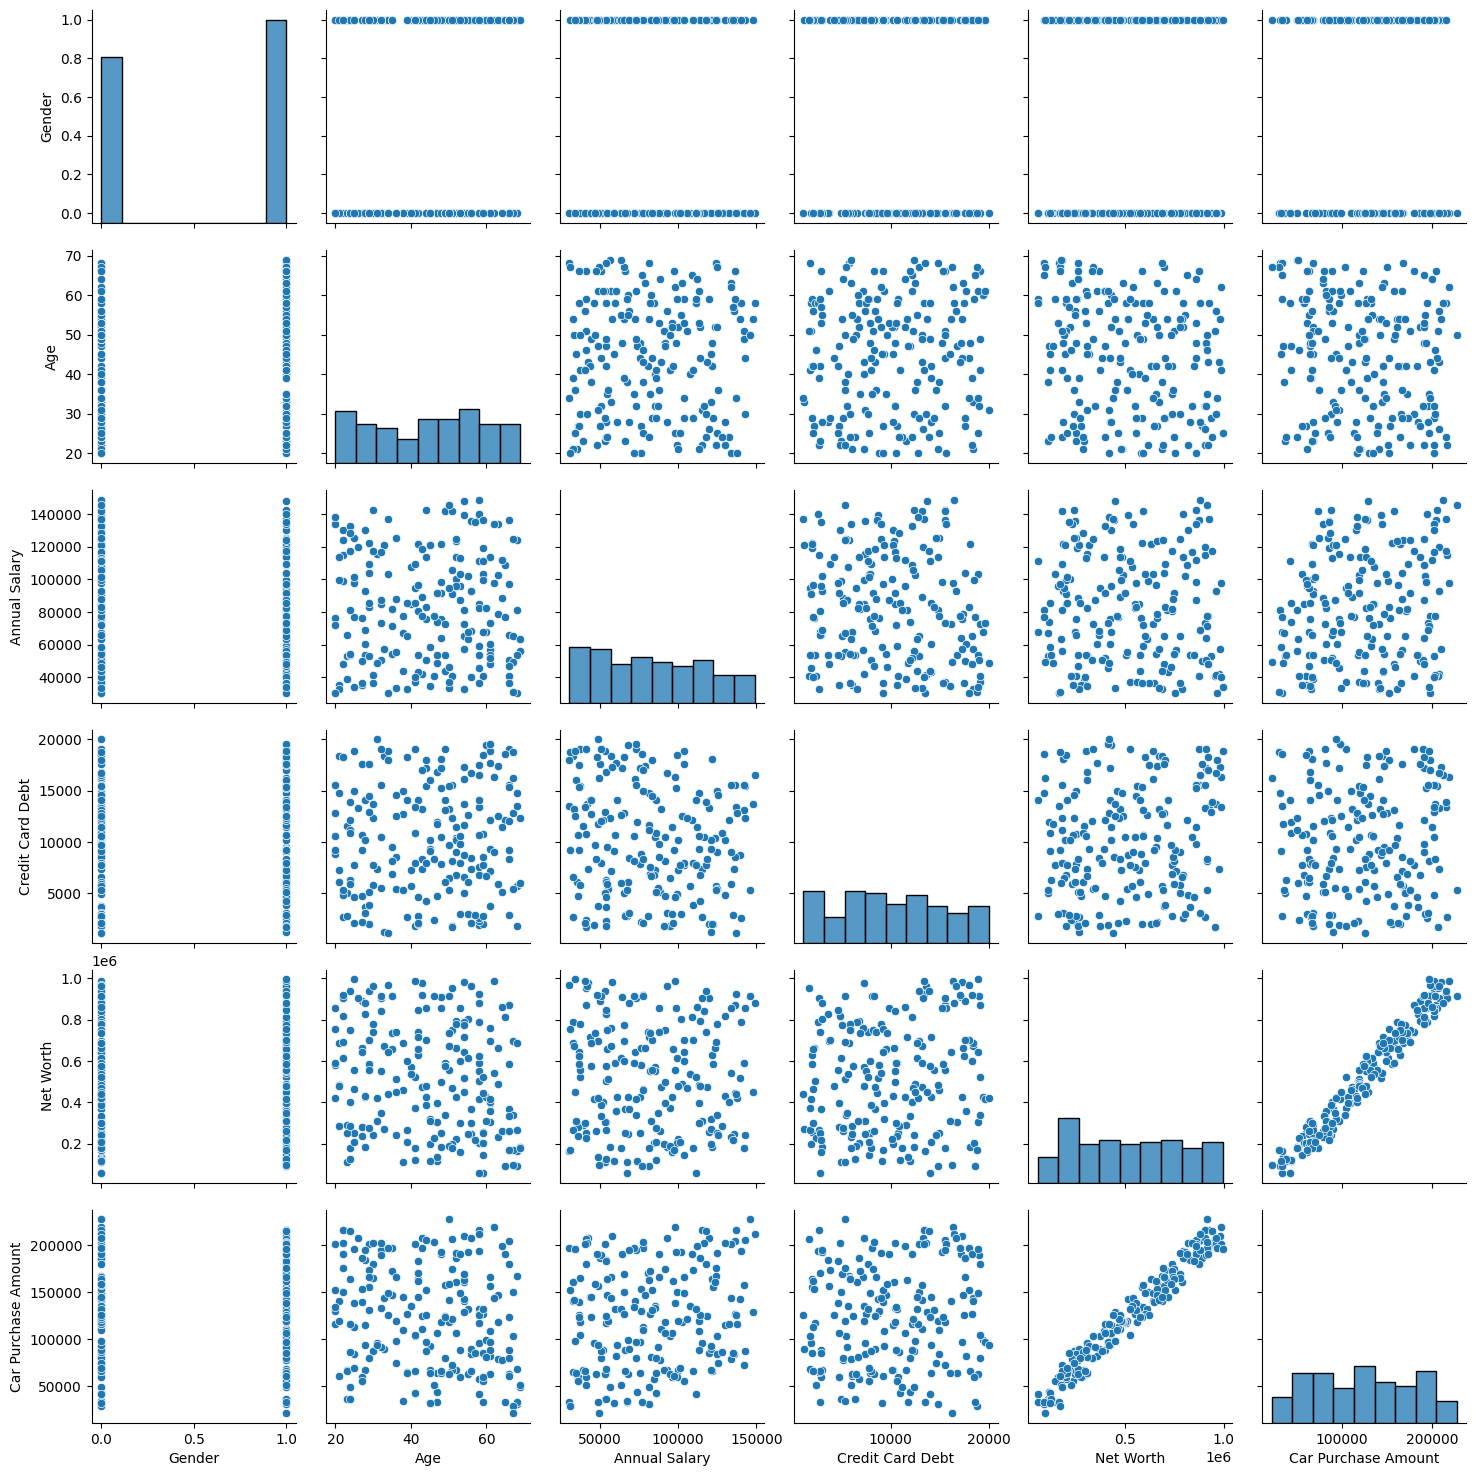

In [6]:
# Pairplot
sns.pairplot(car_df)

In [10]:
# Define features (x) and target (y)
x = car_df.drop(['Customer Name', 'Customer Email', 'Country', 'Car Purchase Amount'], axis=1)
y = car_df['Car Purchase Amount']
x

,Gender,Age,Annual Salary,Credit Card Debt,Net Worth
0,0,58,45795,1860,415838
1,1,40,84886,7265,571430
2,1,30,142727,12363,241335
3,1,41,94820,1769,371879
4,0,21,35311,6051,285796
...,...,...,...,...,...
195,0,25,101158,7767,208211
196,0,49,43918,14046,573138
197,0,50,145751,5324,912755
198,0,50,46389,9659,734106


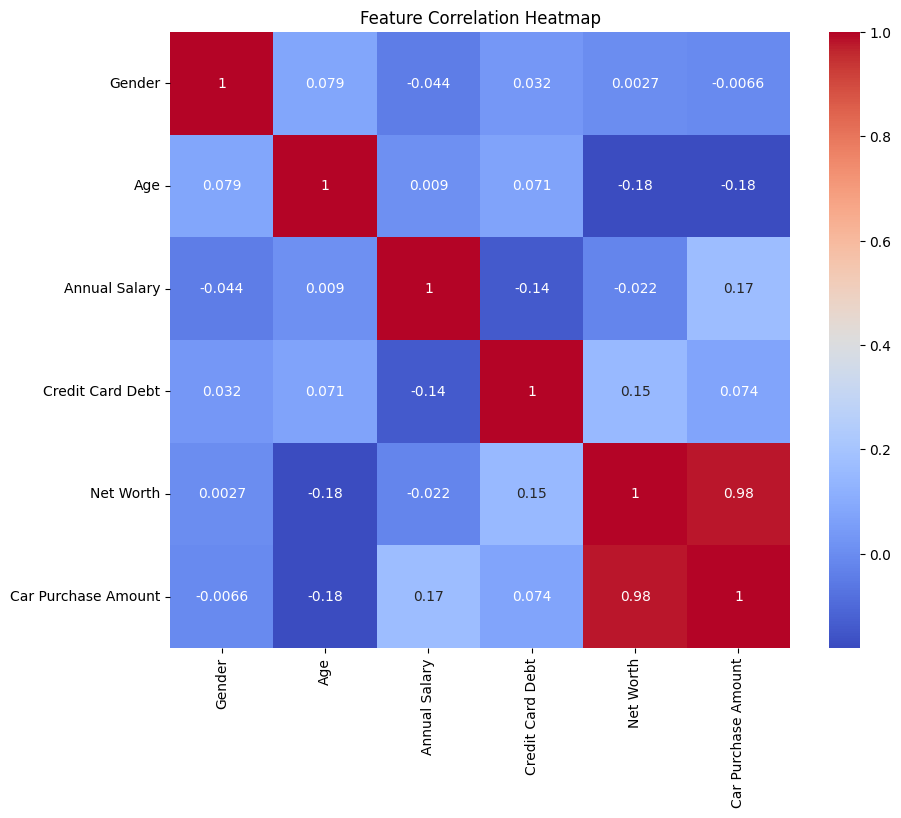

In [11]:
# Correlation Heatmap
plt.figure(figsize=(10,8))
df_for_corr = pd.concat([x, y], axis=1)
sns.heatmap(df_for_corr.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

In [12]:
print(x.shape)
print(y.shape)

(200, 5)
(200,)


Feature Scaling

In [13]:
# Separate scalers
x_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

x_scaled = x_scaler.fit_transform(x)

y = y.values.reshape(-1,1)
y_scaled = y_scaler.fit_transform(y)

Train - Test Split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    x_scaled, y_scaled, test_size=0.25, random_state=42
)

print(X_train.shape, X_test.shape)

(150, 5) (50, 5)


Build ANN Model

In [15]:
model = Sequential()

model.add(Dense(25, input_dim=X_train.shape[1], activation='relu'))
model.add(Dense(25, activation='relu'))
model.add(Dense(1, activation='linear'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 25)             │           150 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 25)             │           650 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 826 (3.23 KB)

 Trainable params: 826 (3.23 KB)

 Non-trainable params: 0 (0.00 B)

Compile and Train Model

In [16]:
model.compile(optimizer='adam', loss='mean_squared_error')

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.1885 - val_loss: 0.1796
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1511 - val_loss: 0.1392
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.1183 - val_loss: 0.1045
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0902 - val_loss: 0.0761
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0699 - val_loss: 0.0545
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0534 - val_loss: 0.0397
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0459 - val_loss: 0.0303
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0407 - val_loss: 0.0256
Epoch 9/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0380 - val_loss: 0.0233
Epoch 10/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0361 - val_loss: 0.0217
Epoch 11/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0336 - val_loss: 0.0201
Epoch 12/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0305 - val_loss: 0.0187
E

Training Visualization

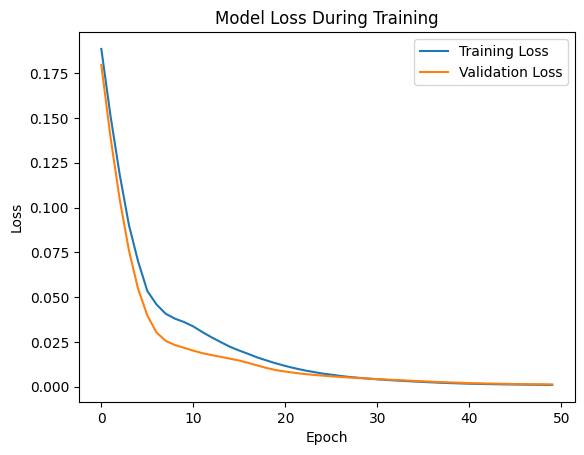

In [17]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss During Training')
plt.ylabel('Loss')
plt.xlabel('Epoch')

plt.legend(['Training Loss', 'Validation Loss'])
plt.show()

Model Evaluation

In [18]:
y_pred = model.predict(X_test)

# Convert back to original scale
y_pred_actual = y_scaler.inverse_transform(y_pred)
y_test_actual = y_scaler.inverse_transform(y_test)

rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))

print("ANN RMSE:", rmse)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
ANN RMSE: 6742.043331342524


Baseline Model (Linear Regression)

In [19]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_pred_actual = y_scaler.inverse_transform(lr_pred)

rmse_lr = np.sqrt(mean_squared_error(y_test_actual, lr_pred_actual))

print("Linear Regression RMSE:", rmse_lr)

Linear Regression RMSE: 2873.1854758591157


Sample Prediction

In [20]:
# Example customer
sample = np.array([[1, 50, 50000, 10000, 600000]])

# Scale input
sample_scaled = x_scaler.transform(sample)

# Predict
prediction_scaled = model.predict(sample_scaled)

# Convert back
prediction = y_scaler.inverse_transform(prediction_scaled)

print("Predicted Car Purchase Amount:", prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Predicted Car Purchase Amount: [[132224.03]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


## 📌 Conclusion

- The ANN model successfully captures the relationship between financial attributes and car purchase amount.
- The model performs reasonably well based on RMSE.
- Linear Regression was used as a baseline for comparison.

## 🚀 Future Improvements
- Hyperparameter tuning
- Try advanced models like XGBoost
- Deploy using Streamlit